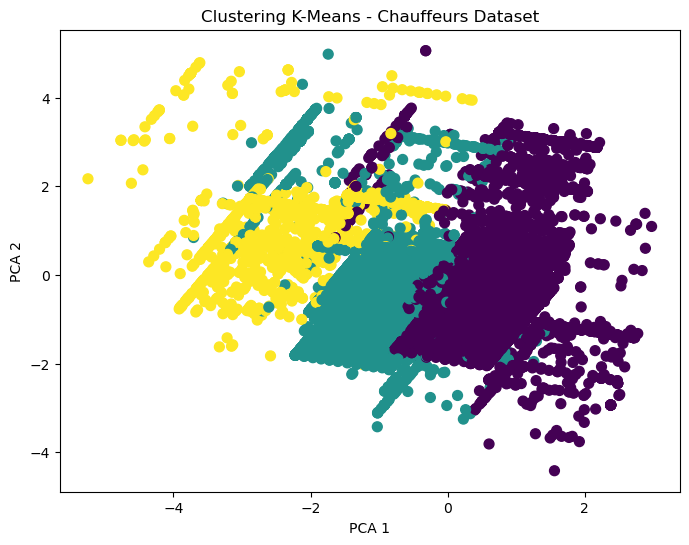

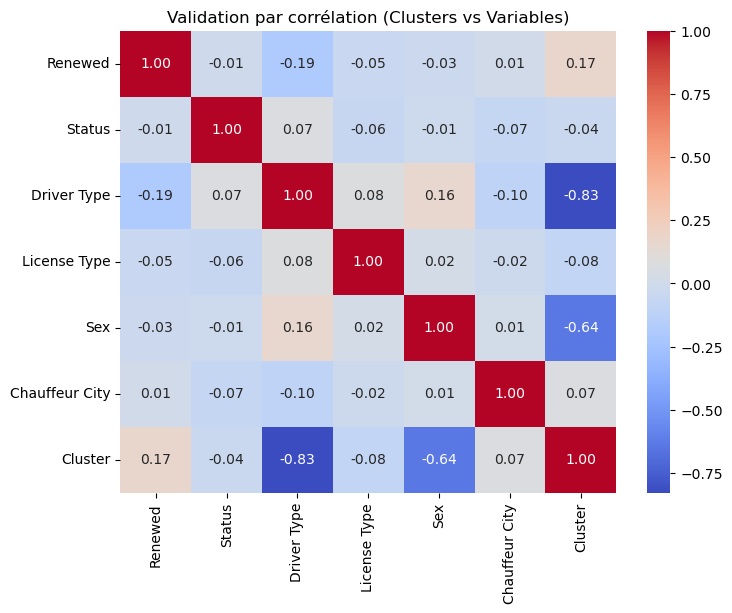


Corrélation avec Cluster :
Cluster           1.000000
Renewed           0.170524
Chauffeur City    0.070578
Status           -0.038414
License Type     -0.081111
Sex              -0.637334
Driver Type      -0.827587
Name: Cluster, dtype: float64


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# 2. Colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# 3. Encodage
label_encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 4. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 5. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Ajouter les clusters
df["Cluster"] = labels

# 6. PCA pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 7. Visualisation
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50)
plt.title("Clustering K-Means - Chauffeurs Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 8. Validation par corrélation
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Validation par corrélation (Clusters vs Variables)")
plt.show()

# Affichage corrélation avec Cluster uniquement
print("\nCorrélation avec Cluster :")
print(corr["Cluster"].sort_values(ascending=False))

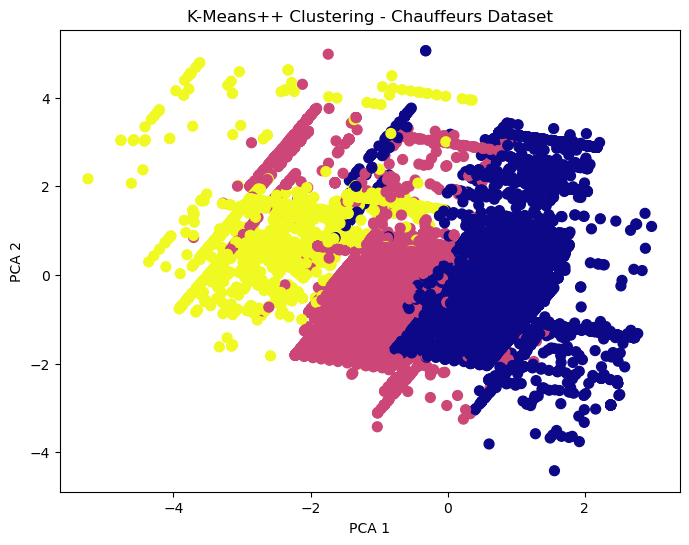

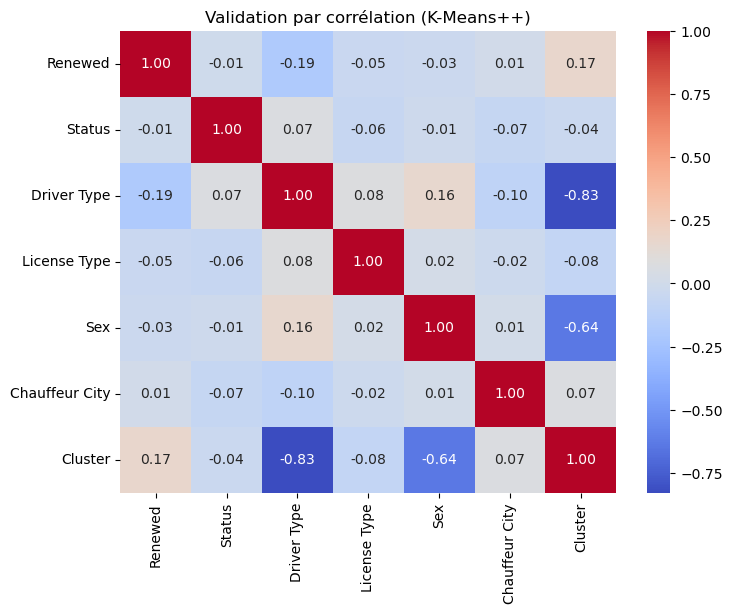


Corrélation avec Cluster :
Cluster           1.000000
Renewed           0.170524
Chauffeur City    0.070578
Status           -0.038414
License Type     -0.081111
Sex              -0.637334
Driver Type      -0.827587
Name: Cluster, dtype: float64


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# 2. Sélection des colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# 3. Encodage des variables catégorielles
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# 4. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 5. K-Means++
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Ajouter clusters au dataset
df["Cluster"] = labels

# 6. PCA pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 7. Visualisation
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='plasma', s=50)

plt.title("K-Means++ Clustering - Chauffeurs Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# 8. Validation par corrélation
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Validation par corrélation (K-Means++)")
plt.show()

# Corrélation avec Cluster uniquement
print("\nCorrélation avec Cluster :")
print(corr["Cluster"].sort_values(ascending=False))

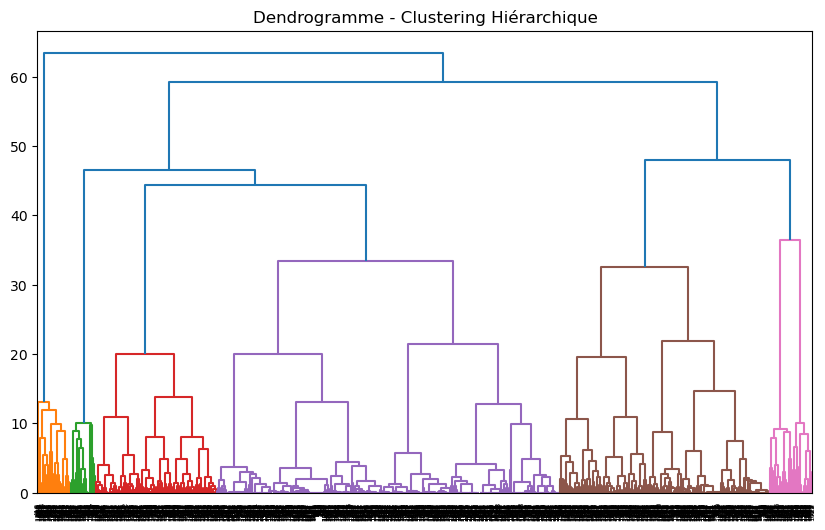

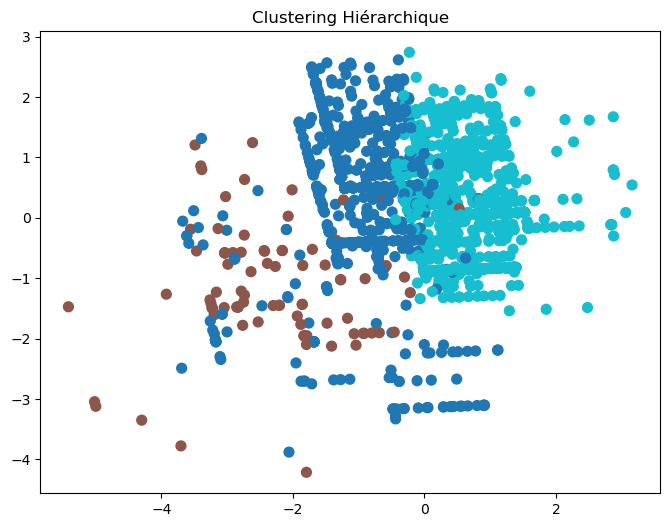

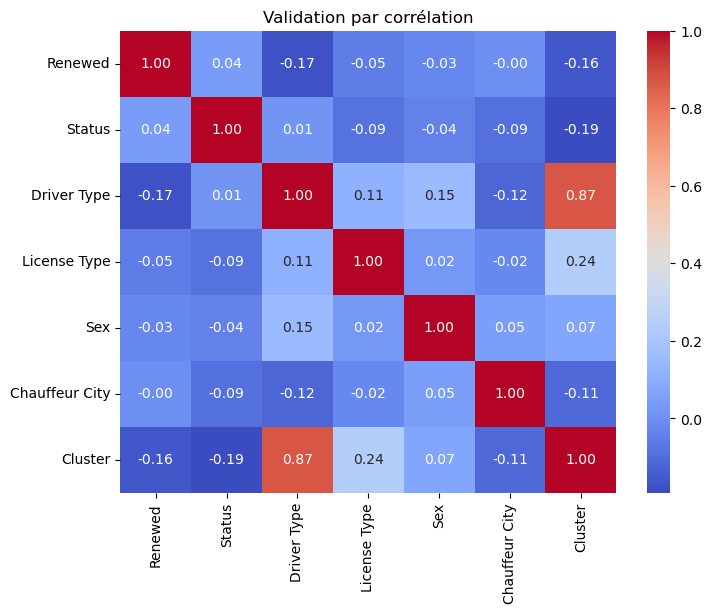


Corrélation avec Cluster :
Cluster           1.000000
Driver Type       0.872445
License Type      0.237144
Sex               0.072597
Chauffeur City   -0.108685
Renewed          -0.161082
Status           -0.191704
Name: Cluster, dtype: float64


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# 2. Sélection des colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# 3. Encodage
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# 4. Échantillon
df = df.sample(2000, random_state=42)

# 5. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 6. Dendrogramme
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogramme - Clustering Hiérarchique")
plt.show()

# 7. Clustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = hc.fit_predict(X_scaled)

# Ajouter clusters
df["Cluster"] = labels

# 8. PCA (visualisation)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=50)
plt.title("Clustering Hiérarchique")
plt.show()

# 9. Validation par corrélation 
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Validation par corrélation")
plt.show()

# Corrélation avec cluster uniquement
print("\nCorrélation avec Cluster :")
print(corr["Cluster"].sort_values(ascending=False))

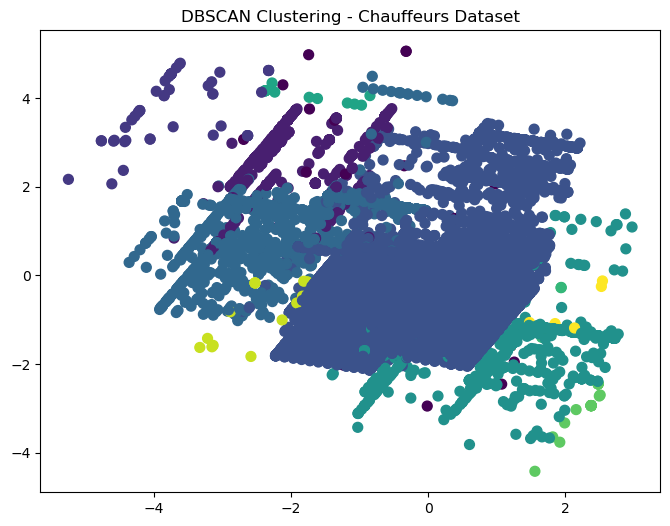

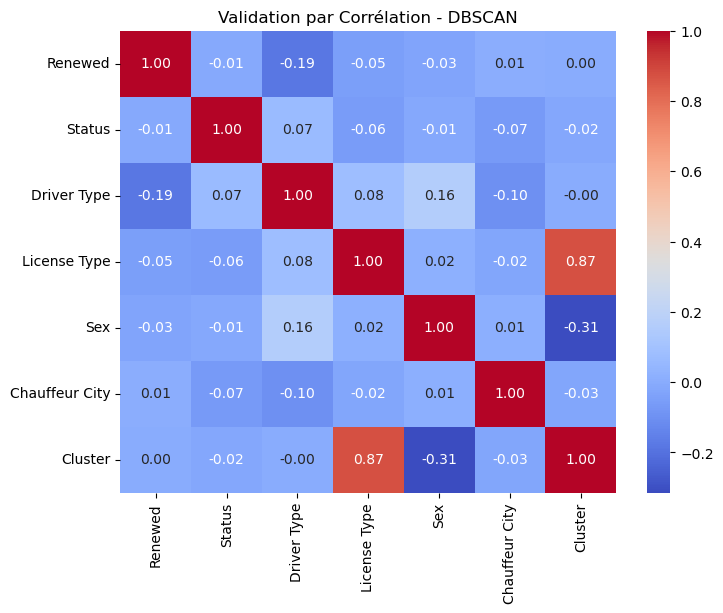


Corrélation avec Cluster :
Cluster           1.000000
License Type      0.871664
Renewed           0.003053
Driver Type      -0.001048
Status           -0.019502
Chauffeur City   -0.026119
Sex              -0.314371
Name: Cluster, dtype: float64


In [4]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# Sélection des colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# Encodage
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Ajouter clusters au dataset
df["Cluster"] = labels

# PCA pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50)

plt.title("DBSCAN Clustering - Chauffeurs Dataset")
plt.show()

# CORRÉLATION
corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Validation par Corrélation - DBSCAN")
plt.show()

# Corrélation avec cluster
print("\nCorrélation avec Cluster :")
print(corr["Cluster"].sort_values(ascending=False))